# FRM Parte I, libro 3: Mercados y productos financieros

| Caso | Tema del programa |
|---|---|
| 1 | Tasas de interés: capitalización, tasas forward y FRA |
| 2 | Mercados de futuros: liquidación diaria y llamados de margen |
| 3 | Forwards de divisas y paridad cubierta de tasas |
| 4 | Cobertura con futuros: razón de mínima varianza y ajuste de beta |
| 5 | Opciones: estrategias y paridad put-call |
| 6 | Swaps de tasa de interés: tasa par y valor de mercado |
| 7 | Forwards de commodities: costo de acarreo |
| 8 | Hipotecas y MBS: prepago y vida promedio |
| 9 | Cámaras de compensación: compensación bilateral y multilateral |

## Configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dsaplicado import bcch, datos, frm, portafolio as pf, tasas
from dsaplicado.graficos import COLORES, NEUTRO, TINTA, TINTA_SECUNDARIA, TINTA_TENUE, aplicar_estilo, eje_porcentaje

aplicar_estilo()
pd.set_option("display.float_format", "{:,.4f}".format)
RAIZ = datos.raiz_repositorio()
FIGURAS = RAIZ / "05_FRM" / "figuras"

swap = bcch.cargar_series({}, None, None, RAIZ / "datos" / "bcch" / "swap_camara_pesos.csv").dropna() / 100
PLAZOS = np.array([float(c) for c in swap.columns])
dolar = datos.cargar_indicador(RAIZ / "datos" / "dolar_historico.csv", "dolar", range(2000, 2027))
ust_1a = datos.cargar_fred("DGS1", RAIZ / "datos" / "fred") / 100
hoy = swap.index[-1]
print(f"Curva swap al {hoy:%d-%m-%Y}:", {f"{p:g} años": f"{t:.2%}" for p, t in zip(PLAZOS, swap.iloc[-1])})

Curva swap al 23-09-2026: {'0.25 años': '4.57%', '0.5 años': '4.59%', '1 años': '4.78%', '2 años': '5.14%', '3 años': '5.31%', '4 años': '5.44%', '5 años': '5.54%', '10 años': '5.90%'}


## Caso 1. Tasas de interés: capitalización, tasas forward y FRA

**Concepto.** Una tasa con $m$ capitalizaciones al año equivale a una tasa continua $R_c = m\ln(1 + R_m/m)$. Con tasas cero continuas, la tasa forward entre $T_1$ y $T_2$ es

$$R_F = \frac{R_2 T_2 - R_1 T_1}{T_2 - T_1}$$

Un FRA fija hoy la tasa de un préstamo futuro. Para quien recibe la tasa fija $R_K$ sobre un nocional $L$, vale $L\,(R_K - R_F)(T_2 - T_1)\,e^{-R_2 T_2}$.

                                           continua equivalente
capitalizaciones al año de una tasa de 6%                      
1                                                       5.8269%
2                                                       5.9118%
4                                                       5.9554%
12                                                      5.9850%
365                                                     5.9995%


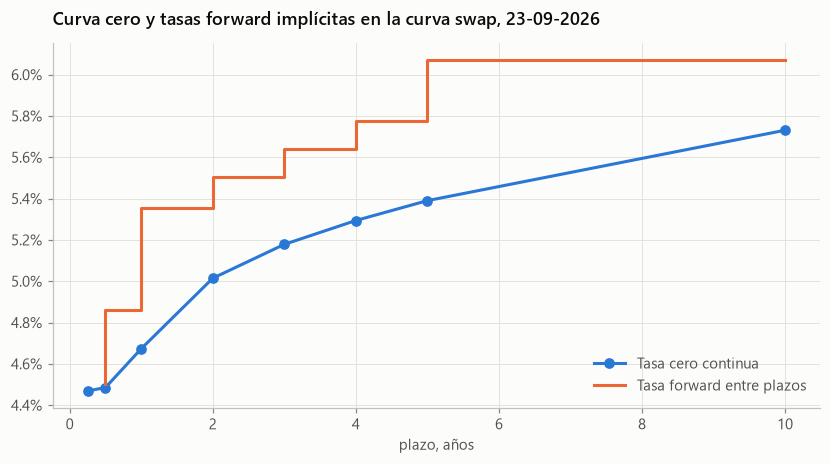

In [2]:
equivalencias = pd.DataFrame({m: {"continua equivalente": frm.tasa_continua(0.06, m)}
                              for m in [1, 2, 4, 12, 365]}).T
equivalencias.index.name = "capitalizaciones al año de una tasa de 6%"
print(equivalencias.to_string(float_format=lambda v: f"{v:.4%}"))

cero = np.log1p(swap.iloc[-1].to_numpy())          # tasas anuales convertidas a continuas
forwards = frm.tasas_forward(PLAZOS, cero)
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(PLAZOS, cero, marker="o", color=COLORES[0], linewidth=2, label="Tasa cero continua")
ax.step(PLAZOS[1:], forwards, where="pre", color=COLORES[1], linewidth=2, label="Tasa forward entre plazos")
eje_porcentaje(ax, decimales=1)
ax.set_xlabel("plazo, años")
ax.set_title(f"Curva cero y tasas forward implícitas en la curva swap, {hoy:%d-%m-%Y}")
ax.legend(loc="lower right")
plt.show()

In [3]:
# FRA: recibir 5% fijo sobre $10.000 millones entre el año 1 y el año 2.
nocional, tasa_fra = 10_000_000_000, 0.05
r1, r2 = cero[PLAZOS == 1][0], cero[PLAZOS == 2][0]
forward_1_2 = (r2 * 2 - r1 * 1) / (2 - 1)
forward_simple = np.exp(forward_1_2) - 1           # la tasa del FRA se cotiza anual
valor_fra = nocional * (tasa_fra - forward_simple) * 1 * np.exp(-r2 * 2)
print(f"Tasa forward entre 1 y 2 años: {forward_simple:.3%}")
print(f"Valor del FRA para quien recibe {tasa_fra:.1%}: ${valor_fra:,.0f}")

Tasa forward entre 1 y 2 años: 5.502%
Valor del FRA para quien recibe 5.0%: $-45,370,683


**Lectura.**

- **La frecuencia de capitalización importa poco con tasas bajas, pero no es cero.** Una tasa de 6% anual equivale a 5,83% continua; una de 6% con capitalización diaria, a casi 6%.
- **La curva sube, así que las tasas forward quedan sobre las tasas cero.** El mercado cobra 5,5% por prestar entre el año 1 y el año 2, más que el 4,8% a un año.
- **El FRA pactado a 5% pierde valor.** Quien recibe 5% cuando el mercado exige 5,5% pierde unos $45 millones sobre un nocional de $10.000 millones.

**Para el examen.**

- Si la curva cero sube con el plazo, las tasas forward quedan sobre las tasas cero; si baja, quedan bajo ellas.
- Teorías de la estructura temporal: expectativas, preferencia por liquidez, que exige un premio por plazo, y segmentación de mercado.
- Convenciones de conteo de días: real/real para bonos del Tesoro de Estados Unidos, 30/360 para bonos corporativos y real/360 para instrumentos del mercado monetario.

## Caso 2. Liquidación diaria y llamados de margen

**Concepto.** En un futuro, las ganancias y pérdidas se liquidan cada día contra la cuenta de margen. Si el saldo cae bajo el margen de mantención, el inversionista recibe un llamado de margen y debe reponerlo hasta el margen inicial.

Un exportador vende futuros por US$10 millones para cubrirse justo antes del estallido social de octubre de 2019, con un margen inicial supuesto de $400 millones y uno de mantención de $300 millones.

In [4]:
posicion_usd = -10_000_000                    # venta de dólares a futuro
margen_inicial, margen_mantencion = 400_000_000, 300_000_000
precios_futuro = dolar.loc["2019-10-11":"2019-12-13"]   # se usa el dólar observado como aproximación del futuro
saldo, filas = margen_inicial, []
for fecha, cambio in precios_futuro.diff().dropna().items():
    ganancia = posicion_usd * cambio
    saldo += ganancia
    aporte = margen_inicial - saldo if saldo < margen_mantencion else 0.0
    saldo += aporte
    filas.append({"fecha": fecha, "dólar": precios_futuro.loc[fecha], "ganancia diaria": ganancia,
                  "llamado de margen": aporte, "saldo tras el aporte": saldo})
cuenta = pd.DataFrame(filas).set_index("fecha")
print(f"Dólar: de {precios_futuro.iloc[0]:.0f} a {precios_futuro.max():.0f} pesos en su máximo")
print(f"Llamados de margen: {(cuenta['llamado de margen'] > 0).sum()}, por un total de ${cuenta['llamado de margen'].sum():,.0f}")
cuenta[cuenta["llamado de margen"] > 0].style.format({"dólar": "{:.1f}", "ganancia diaria": "{:,.0f}",
                                                      "llamado de margen": "{:,.0f}", "saldo tras el aporte": "{:,.0f}"})

Dólar: de 721 a 828 pesos en su máximo
Llamados de margen: 7, por un total de $1,076,400,000


,dólar,ganancia diaria,llamado de margen,saldo tras el aporte
fecha,,,,
2019-11-04 00:00:00,735.0,"-87,100,000","144,400,000","400,000,000"
2019-11-06 00:00:00,745.9,"-91,900,000","108,000,000","400,000,000"
2019-11-12 00:00:00,756.1,"-98,500,000","102,300,000","400,000,000"
2019-11-13 00:00:00,783.7,"-276,400,000","276,400,000","400,000,000"
2019-11-14 00:00:00,794.5,"-107,900,000","107,900,000","400,000,000"
2019-11-28 00:00:00,806.3,"-128,100,000","117,900,000","400,000,000"
2019-11-29 00:00:00,828.2,"-219,500,000","219,500,000","400,000,000"


**Lectura.** En dos meses el dólar subió de 721 a 828 pesos. La posición vendida perdió cada día que el dólar subía, y el exportador recibió 7 llamados de margen por más de $1.000 millones en total. Económicamente la cobertura funcionó, porque sus ventas en dólares valían más, pero ese dinero llegaría recién cuando cobrara sus exportaciones. Mientras tanto tuvo que financiar los márgenes.

**Para el examen.**

- En un forward la ganancia se realiza al vencimiento; en un futuro, cada día. Por eso el futuro tiene riesgo de liquidez aunque la cobertura sea perfecta en valor. Es la lección de Metallgesellschaft.
- El llamado de margen repone hasta el margen inicial, no hasta el de mantención.
- La cámara de compensación es la contraparte de ambas partes, lo que elimina casi todo el riesgo de crédito entre ellas.

## Caso 3. Forwards de divisas y paridad cubierta de tasas

**Concepto.** Para que no haya arbitraje, el forward de divisas debe cumplir

$$F = S \cdot \left(\frac{1 + r_{\text{CLP}}}{1 + r_{\text{USD}}}\right)^T$$

La moneda con mayor tasa de interés se transa con descuento a futuro. Se calcula el forward a un año con la tasa swap en pesos y la del bono del Tesoro de Estados Unidos.

In [5]:
anual = pd.DataFrame({"spot": dolar, "r_clp": swap["1"], "r_usd": ust_1a}).dropna()
anual["forward_1a"] = frm.forward_divisas(anual["spot"], anual["r_clp"], anual["r_usd"], 1)
anual["puntos_forward"] = anual["forward_1a"] - anual["spot"]
ultimo = anual.iloc[-1]
print(f"{anual.index[-1]:%d-%m-%Y}: spot {ultimo['spot']:.2f}, tasa en pesos {ultimo['r_clp']:.2%}, "
      f"tasa en dólares {ultimo['r_usd']:.2%}, forward a un año {ultimo['forward_1a']:.2f} ({ultimo['puntos_forward']:+.2f} pesos)")

realizado = anual["spot"].reindex(anual.index + pd.DateOffset(years=1), method="nearest").to_numpy()
anual["spot_un_año_despues"] = realizado
anual = anual[anual.index + pd.DateOffset(years=1) <= anual.index[-1]]
error_forward = (anual["spot_un_año_despues"] / anual["forward_1a"] - 1)
error_ingenuo = (anual["spot_un_año_despues"] / anual["spot"] - 1)
print(f"\nError cuadrático medio al pronosticar el dólar a un año con el forward: {np.sqrt((error_forward**2).mean()):.1%}")
print(f"Con el spot de hoy como pronóstico: {np.sqrt((error_ingenuo**2).mean()):.1%}")

23-09-2026: spot 945.87, tasa en pesos 4.78%, tasa en dólares 4.49%, forward a un año 948.53 (+2.66 pesos)

Error cuadrático medio al pronosticar el dólar a un año con el forward: 10.8%
Con el spot de hoy como pronóstico: 11.6%


**Lectura.**

- **El forward casi no difiere del spot hoy.** Las tasas a un año en pesos y en dólares son parecidas, de 4,8% y 4,5%, así que el forward queda apenas 2,7 pesos sobre el spot.
- **El forward no es un buen pronóstico.** Su error al anticipar el dólar a un año es de 10,8%, casi igual al de suponer que el dólar no se mueve. El forward refleja el diferencial de tasas, no una predicción del mercado.

**Para el examen.**

- La paridad cubierta es una condición de no arbitraje y se cumple muy de cerca. La paridad no cubierta, que supone que el forward pronostica el spot futuro, en la práctica falla.
- Si $F$ es mayor que lo que implica la paridad, se arbitra vendiendo forward, pidiendo prestado en la moneda local, comprando divisa al contado e invirtiéndola en la tasa extranjera.
- En tiempo continuo: $F = S\,e^{(r - r_f)T}$.

## Caso 4. Cobertura con futuros

**Concepto.** La razón de cobertura que minimiza la varianza es $h^* = \rho\,\sigma_S/\sigma_F$, y su efectividad es $\rho^2$. Para cambiar la beta de una cartera de acciones con futuros sobre índice se usan $N = (\beta^* - \beta)\,P/F$ contratos.

Se cubre la cartera de pesos iguales de nueve acciones con el ETF IPSA, que hace de aproximación a un futuro sobre el índice.

In [6]:
precios = datos.cargar_precios(RAIZ / "datos" / "precios_ipsa.csv", {**datos.ACCIONES_IPSA, **datos.BENCHMARK_IPSA},
                               "2019-01-01", "2026-09-01").ffill()
retornos = pf.retornos_simples(precios).dropna()
cartera = retornos[list(datos.ACCIONES_IPSA.values())].mean(axis=1)
futuro = retornos["ETF IPSA"]
rho, sigma_s, sigma_f = cartera.corr(futuro), cartera.std(), futuro.std()
h = frm.razon_cobertura_minima_varianza(rho, sigma_s, sigma_f)
cubierta = cartera - h * futuro
print(f"Correlación {rho:.3f}, razón de mínima varianza h* = {h:.3f}, efectividad rho² = {rho**2:.1%}")
print(f"Volatilidad anual sin cubrir {sigma_s * np.sqrt(252):.1%}; cubierta {cubierta.std() * np.sqrt(252):.1%}")

valor_cartera, valor_contrato = 10_000_000_000, 50_000_000   # $10.000 millones; contrato supuesto de $50 millones
print(f"\nContratos para cubrir la cartera completa: {frm.contratos_cobertura(h, valor_cartera, valor_contrato):.0f} (venta)")
print(f"Contratos para bajar la beta de {h:.2f} a 0,5: {frm.contratos_ajuste_beta(h, 0.5, valor_cartera, valor_contrato):.0f}")

Correlación 0.818, razón de mínima varianza h* = 0.863, efectividad rho² = 67.0%
Volatilidad anual sin cubrir 22.8%; cubierta 13.1%

Contratos para cubrir la cartera completa: 173 (venta)
Contratos para bajar la beta de 0.86 a 0,5: -73


**Lectura.**

- **La razón óptima es 0,86, no 1.** La cartera se mueve menos que el índice, así que cubrirla peso a peso la sobrecubriría.
- **La cobertura elimina el 67% de la varianza,** el cuadrado de la correlación de 0,82. La volatilidad anual baja de 22,8% a 13,1%. El resto es riesgo propio de las acciones que el índice no captura: el riesgo de base.
- **Con contratos supuestos de $50 millones,** cubrir una cartera de $10.000 millones requiere vender 173, y bajar su beta de 0,86 a 0,5 requiere vender 73.

**Para el examen.**

- Riesgo de base: la base es el precio spot menos el del futuro. La cobertura elimina el riesgo de precio pero no el de base.
- Una cobertura larga compra futuros para fijar el costo de una compra futura; una corta vende futuros para fijar el precio de una venta futura.
- Con futuros sobre índice, la razón de mínima varianza coincide con la beta de la cartera frente al índice.
- Ajuste por liquidación diaria (tailing the hedge): se usa la razón de valores $V_A/V_F$ en vez de cantidades.

## Caso 5. Opciones: estrategias y paridad put-call

**Concepto.** La paridad put-call de opciones europeas es $c + K e^{-rT} = p + S_0$. Para divisas se reemplaza $S_0$ por $S_0 e^{-r_f T}$. Se valoran opciones a tres meses sobre el dólar con el modelo de Garman-Kohlhagen y se grafican cuatro estrategias clásicas.

Spot 945.87, volatilidad histórica 10.8%. Call y put con strike 946: 20.09 y 20.04
Paridad put-call: c + K·e^(-rT) = 955.5839 y p + S·e^(-rf·T) = 955.5839


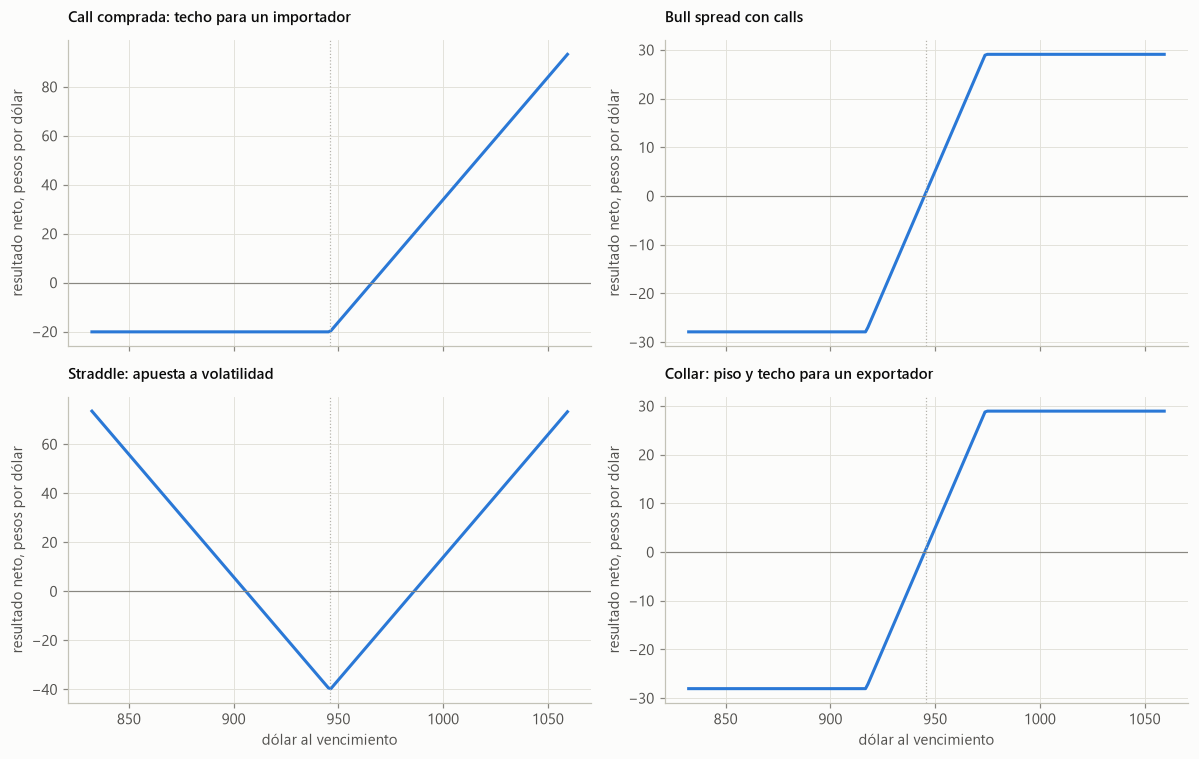

In [7]:
s0 = dolar.loc[:hoy].iloc[-1]
r_clp, r_usd = np.log1p(swap["0.25"].iloc[-1]), np.log1p(ust_1a.iloc[-1])
vol = np.log(dolar).diff().loc["2025":].std() * np.sqrt(252)
T = 0.25
prima = lambda k, tipo: frm.black_scholes(s0, k, r_clp, vol, T, tipo, q=r_usd)
k_bajo, k_medio, k_alto = round(s0 * 0.97), round(s0), round(s0 * 1.03)
print(f"Spot {s0:.2f}, volatilidad histórica {vol:.1%}. Call y put con strike {k_medio}: {prima(k_medio, 'call'):.2f} y {prima(k_medio, 'put'):.2f}")
izquierda = prima(k_medio, "call") + k_medio * np.exp(-r_clp * T)
derecha = prima(k_medio, "put") + s0 * np.exp(-r_usd * T)
print(f"Paridad put-call: c + K·e^(-rT) = {izquierda:.4f} y p + S·e^(-rf·T) = {derecha:.4f}")

estrategias = {
    "Call comprada: techo para un importador": [("call", k_medio, 1, prima(k_medio, "call"))],
    "Bull spread con calls": [("call", k_bajo, 1, prima(k_bajo, "call")), ("call", k_alto, -1, prima(k_alto, "call"))],
    "Straddle: apuesta a volatilidad": [("call", k_medio, 1, prima(k_medio, "call")), ("put", k_medio, 1, prima(k_medio, "put"))],
    "Collar: piso y techo para un exportador": [("subyacente", s0, 1, 0), ("put", k_bajo, 1, prima(k_bajo, "put")),
                                                ("call", k_alto, -1, prima(k_alto, "call"))],
}
finales = np.linspace(s0 * 0.88, s0 * 1.12, 200)
fig, ejes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for ax, (nombre, patas) in zip(ejes.flat, estrategias.items()):
    ax.plot(finales, frm.pago_estrategia(finales, patas), color=COLORES[0], linewidth=2)
    ax.axhline(0, color=TINTA_TENUE, linewidth=0.8)
    ax.axvline(s0, color=NEUTRO, linewidth=0.8, linestyle=":")
    ax.set_title(nombre, fontsize=10)
    ax.set_ylabel("resultado neto, pesos por dólar")
for ax in ejes[1]:
    ax.set_xlabel("dólar al vencimiento")
fig.tight_layout()
fig.savefig(FIGURAS / "estrategias_opciones.png", bbox_inches="tight")
plt.show()

**Lectura.**

- **La paridad put-call se cumple exactamente** con los precios del modelo: ambos lados suman 955,58 pesos.
- **La call comprada** le pone un techo al costo de un importador a cambio de una prima de unos 20 pesos por dólar.
- **El collar y el bull spread tienen exactamente el mismo perfil.** Tener dólares con una put comprada y una call vendida equivale, por paridad put-call, a un spread alcista con calls. Es una pregunta frecuente de examen.
- **El straddle** gana solo si el dólar se mueve más de unos 40 pesos en cualquier dirección.

**Para el examen.**

- Límites de precio: una call europea vale al menos $\max(S_0 - K e^{-rT}, 0)$ y como máximo $S_0$. Una put europea, al menos $\max(K e^{-rT} - S_0, 0)$ y como máximo $K e^{-rT}$.
- Nunca conviene ejercer anticipadamente una call americana sobre una acción sin dividendos; una put americana sí puede convenir.
- Estrategias: covered call, que es acción más call vendida; protective put; spreads alcistas y bajistas; spreads de mariposa y de calendario; straddle, strangle, strip y strap.

## Caso 6. Swaps de tasa de interés

**Concepto.** Un swap de tasa fija contra flotante se valora como la diferencia entre dos bonos. Para quien paga fijo y recibe flotante: $V = B_{\text{flotante}} - B_{\text{fijo}}$. Al inicio, la tasa fija que hace $V = 0$ es la tasa par del swap.

Un banco pagó fijo en un swap a 5 años hace dos años, a la tasa de ese día. ¿Cuánto vale hoy?

In [8]:
inicio = swap.index[swap.index.get_indexer([hoy - pd.DateOffset(years=2)], method="nearest")[0]]
tasa_pactada = swap.loc[inicio, "5"]
restantes = np.arange(0.5, 3.01, 0.5)                                   # quedan 3 años, pagos semestrales
cero_restantes = np.interp(restantes, PLAZOS, cero)
nocional = 10_000_000_000
valor = frm.valor_swap_tasa(nocional, tasa_pactada, restantes, cero_restantes)
par_hoy = frm.tasa_swap_par(restantes, cero_restantes)
print(f"Tasa pactada el {inicio:%d-%m-%Y}: {tasa_pactada:.2%}. Tasa par hoy para los 3 años restantes: {par_hoy:.2%}")
print(f"Valor para quien paga fijo, nocional $10.000 millones: ${valor:,.0f}")

plazos_cotizados = np.array([1, 2, 3, 4, 5, 10])
comparacion = pd.DataFrame({
    "tasa swap cotizada": swap.iloc[-1][[f"{p:g}" for p in plazos_cotizados]].to_numpy(),
    "tasa par calculada con la curva cero": [frm.tasa_swap_par(np.arange(0.5, p + 0.01, 0.5),
                                                                np.interp(np.arange(0.5, p + 0.01, 0.5), PLAZOS, cero))
                                             for p in plazos_cotizados],
}, index=pd.Index(plazos_cotizados, name="años"))
comparacion.style.format("{:.3%}")

Tasa pactada el 23-09-2024: 4.42%. Tasa par hoy para los 3 años restantes: 5.23%
Valor para quien paga fijo, nocional $10.000 millones: $222,113,032


,tasa swap cotizada,tasa par calculada con la curva cero
años,,
1,4.784%,4.726%
2,5.142%,5.067%
3,5.315%,5.229%
4,5.436%,5.342%
5,5.538%,5.434%
10,5.898%,5.739%


**Lectura.**

- **El swap ganó valor para quien paga fijo.** Hace dos años se pactó a 4,42%, y hoy la tasa par para los 3 años restantes es 5,23%. Pagar una tasa bajo la de mercado vale unos $222 millones sobre un nocional de $10.000 millones.
- **Las tasas par calculadas quedan algo bajo las cotizadas,** entre 6 y 16 puntos base. La diferencia viene de tratar las tasas swap cotizadas como si fueran tasas cero. Una curva cero construida contrato a contrato cerraría esa brecha.

**Para el examen.**

- Un swap también se puede valorar como una cartera de FRA, con el mismo resultado que el enfoque de bonos.
- Ventaja comparativa: dos empresas con distintos costos de financiamiento relativos en fijo y flotante pueden ganar ambas con un swap.
- En un swap de monedas se intercambian los nocionales al inicio y al final, lo que genera un riesgo de crédito mayor que en un swap de tasas.

## Caso 7. Forwards de commodities: costo de acarreo

**Concepto.** Para un commodity que se almacena, $F = S\,e^{(r + u - y)T}$, donde $u$ es el costo de almacenamiento y $y$ el rendimiento de conveniencia de tener el bien físico. Si $F$ sube con el plazo, el mercado está en contango; si baja, en backwardation.

Se usa el precio actual del cobre y supuestos ilustrativos para los demás parámetros.

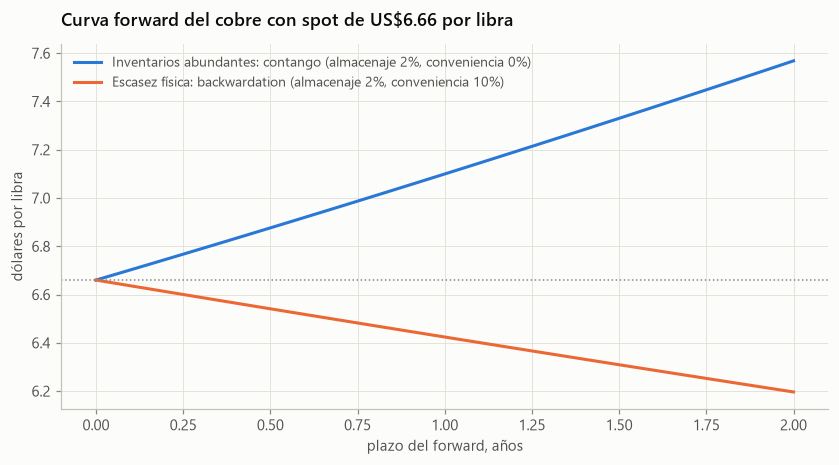

In [9]:
cobre = datos.cargar_indicador(RAIZ / "datos" / "libra_cobre_historico.csv", "libra_cobre", range(2012, 2027))
spot_cobre, r = cobre.iloc[-1], r_usd
plazos_c = np.linspace(0, 2, 25)
fig, ax = plt.subplots(figsize=(9, 4.3))
for k, (nombre, u, y) in enumerate([("Inventarios abundantes: contango", 0.02, 0.0),
                                    ("Escasez física: backwardation", 0.02, 0.10)]):
    ax.plot(plazos_c, [frm.precio_forward(spot_cobre, r + u, t, y) for t in plazos_c], color=COLORES[k], linewidth=2,
            label=f"{nombre} (almacenaje {u:.0%}, conveniencia {y:.0%})")
ax.axhline(spot_cobre, color=TINTA_TENUE, linestyle=":", linewidth=1)
ax.set_xlabel("plazo del forward, años")
ax.set_ylabel("dólares por libra")
ax.set_title(f"Curva forward del cobre con spot de US${spot_cobre:.2f} por libra")
ax.legend(loc="upper left", fontsize=9)
plt.show()

**Para el examen.**

- El rendimiento de conveniencia es alto cuando los inventarios son bajos: tener el bien físico permite seguir produciendo.
- En commodities de consumo no se puede arbitrar vendiendo en corto el físico, por eso el precio forward puede quedar bajo el costo de acarreo.
- Las commodities de inversión, como el oro, se comportan casi como activos financieros; las de consumo, como el cobre o el petróleo, no.

## Caso 8. Hipotecas y bonos respaldados por hipotecas (MBS)

**Concepto.** Una hipoteca con cuota fija amortiza capital cada mes. Los deudores pueden prepagar, sobre todo cuando las tasas bajan y les conviene refinanciar. El prepago se mide con la tasa anual CPR, que equivale a una mensual $SMM = 1 - (1 - CPR)^{1/12}$.

Se modela un pool de hipotecas por $100.000 millones a 30 años y 6% anual con distintos supuestos de prepago.

Cuota mensual inicial del pool: $599,550,525


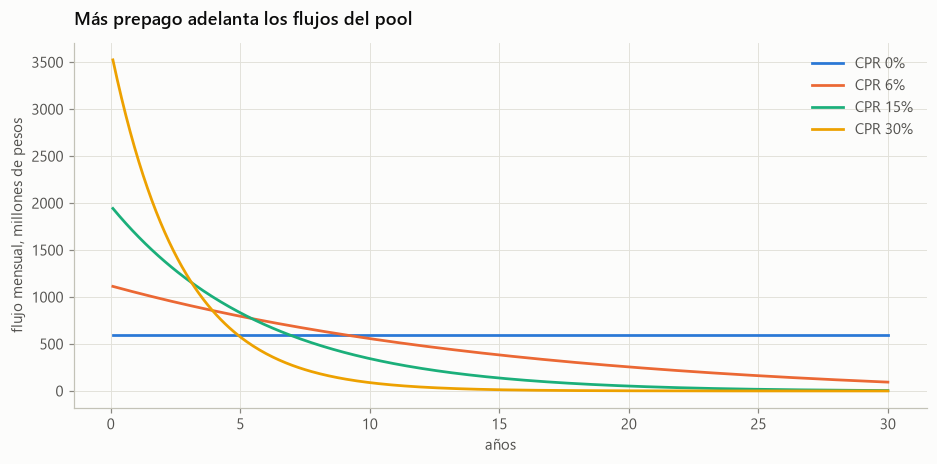

,"vida promedio ponderada, años","intereses totales, millones"
CPR 0%,19.3064,"115,838.1891"
CPR 6%,10.5976,"63,585.8272"
CPR 15%,5.5135,"33,081.2969"
CPR 30%,2.7330,"16,398.0744"


In [10]:
principal = 100_000_000_000
perfiles = {}
resumen = {}
for cpr in [0.0, 0.06, 0.15, 0.30]:
    flujos = frm.flujos_hipoteca(principal, 0.06, 360, cpr)
    capital = flujos["amortizacion"] + flujos["prepago"]
    perfiles[cpr] = flujos.set_index("mes")["flujo_total"]
    resumen[f"CPR {cpr:.0%}"] = {"vida promedio ponderada, años": (capital * flujos["mes"]).sum() / capital.sum() / 12,
                                 "intereses totales, millones": flujos["interes"].sum() / 1e6}
print(f"Cuota mensual inicial del pool: ${frm.cuota_hipotecaria(principal, 0.06, 360):,.0f}")

fig, ax = plt.subplots(figsize=(10, 4.3))
for k, (cpr, serie) in enumerate(perfiles.items()):
    ax.plot(serie.index / 12, serie / 1e6, color=COLORES[k], linewidth=1.8, label=f"CPR {cpr:.0%}")
ax.set_xlabel("años")
ax.set_ylabel("flujo mensual, millones de pesos")
ax.set_title("Más prepago adelanta los flujos del pool")
ax.legend(loc="upper right")
plt.show()
pd.DataFrame(resumen).T

**Lectura.** Sin prepago, la vida promedio ponderada del pool es de 19 años. Con un CPR de 15% cae a 5,5 años, y con 30% a menos de 3. El inversionista del MBS no sabe cuándo recibirá su capital: depende de las decisiones de refinanciamiento de miles de deudores, que a su vez dependen de las tasas.

**Para el examen.**

- Riesgo de prepago: cuando las tasas bajan, los deudores refinancian y el inversionista recibe su capital justo cuando tiene que reinvertirlo a tasas menores. Por eso los MBS tienen convexidad negativa.
- Riesgo de extensión: cuando las tasas suben, el prepago cae y el MBS se alarga justo cuando se desearía lo contrario.
- La convención del mercado de Estados Unidos es el modelo PSA, en que el CPR sube linealmente durante los primeros 30 meses.

## Caso 9. Cámaras de compensación: compensación bilateral y multilateral

**Concepto.** Cuando todas las operaciones pasan por una contraparte central, cada participante compensa todas sus posiciones contra ella. La exposición total del sistema cae mucho frente a la compensación entre pares.

Se usan cuatro bancos con las siguientes deudas entre sí, en miles de millones de pesos.

In [11]:
bancos = ["Banco A", "Banco B", "Banco C", "Banco D"]
deudas = pd.DataFrame([[0, 40, 10, 30], [20, 0, 50, 10], [30, 10, 0, 40], [10, 30, 20, 0]], index=bancos, columns=bancos)
print("Lo que cada banco de la fila le debe al de la columna:")
print(deudas.to_string())
bruta = deudas.to_numpy().sum()
pd.Series({"exposición bruta": bruta,
           "con compensación bilateral": frm.exposicion_neta(deudas, multilateral=False),
           "con contraparte central": frm.exposicion_neta(deudas, multilateral=True)}).to_frame("miles de millones")

Lo que cada banco de la fila le debe al de la columna:
         Banco A  Banco B  Banco C  Banco D
Banco A        0       40       10       30
Banco B       20        0       50       10
Banco C       30       10        0       40
Banco D       10       30       20        0


,miles de millones
exposición bruta,300.0000
con compensación bilateral,140.0000
con contraparte central,20.0000


**Lectura.** La exposición bruta entre los cuatro bancos es de 300 mil millones. Compensando por pares cae a 140, y con una contraparte central queda en solo 20: cada banco compensa todas sus posiciones contra la cámara, no solo las que tiene con cada contraparte.

**Para el examen.**

- La contraparte central exige márgenes iniciales y de variación, y mantiene un fondo de garantía que mutualiza pérdidas entre los miembros.
- Ventajas: menos riesgo de crédito bilateral, más transparencia y compensación multilateral. Desventajas: concentra el riesgo en una sola institución y exige colateral de alta calidad.
- Después de la crisis de 2008, los reguladores obligaron a compensar centralmente los derivados extrabursátiles estandarizados.